# 03 — Photo-Adjusted Price Prediction

Combines the ML layer price forecast with the photo-based furnishing condition score
to produce a final adjusted price estimate.

**If no photo is provided:** the base ML prediction passes through unchanged.

**If a photo is provided:** a condition score (0–10) is predicted from the image
and the price is adjusted according to the rule-based table:

| Score | Tier | Adjustment |
|-------|------|------------|
| 8–10 | Excellent | +10% |
| 6–8  | Good      |  +5% |
| 4–6  | Average   |   0% |
| 2–4  | Poor      |  −5% |
| 0–2  | Very Poor | −10% |

**Prerequisites:**
- `03_ml_layer_hybrid/artifacts/hybrid_cluster_bundle.joblib` (layer 03)
- `05_photo_layer/artifacts/condition_model_*.pth` (layer 05, from notebook 02)

In [1]:
# stdlib
import sys
from pathlib import Path

# ── Path setup ─────────────────────────────────────────────────────────────────
HERE = Path.cwd()
REPO_ROOT  = HERE if (HERE / 'hf_data').exists() else HERE.parent
LAYER_ROOT = REPO_ROOT / '05_photo_layer'

# Make 05_photo_layer importable
if str(LAYER_ROOT) not in sys.path:
    sys.path.insert(0, str(LAYER_ROOT))
# Make 03_ml_layer_hybrid importable (needed transitively by yc_photo_condition)
ml_layer = str(REPO_ROOT / '03_ml_layer_hybrid')
if ml_layer not in sys.path:
    sys.path.insert(0, ml_layer)

from yc_photo_condition import (
    load_condition_model,
    predict_with_photo,
    ADJUSTMENT_TIERS,
)
from yc_hybrid_inference import load_bundle

print('Modules loaded.')

Modules loaded.


/home/cloudriver/miniconda3/envs/torch5080/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.8' currently installed).
  from pandas.core import (


## 1. Load models

In [2]:
import warnings

try:
    bundle = load_bundle()
    BUNDLE_AVAILABLE = True
    print(f"Hybrid bundle     : {len(bundle["cluster_bundles"])} clusters")
except FileNotFoundError as e:
    warnings.warn("ML bundle not found — photo-scoring-only mode. " + str(e))
    bundle = None
    BUNDLE_AVAILABLE = False
    print("Bundle not found. Run 03_ml_layer_hybrid notebooks first.")
    print("Photo scoring demo will still run.")

condition_model = load_condition_model()  # picks latest condition_model_*.pth
print(f"Condition model   : loaded (EfficientNet-B0)")

/tmp/ipykernel_7912/418357529.py:8: UserWarning: ML bundle not found — photo-scoring-only mode. Bundle not found: /mnt/c/Users/cloud/iCloudDrive/NUS/PropertyLens/03_ml_layer_hybrid/artifacts/hybrid_cluster_bundle.joblib
  warnings.warn("ML bundle not found — photo-scoring-only mode. " + str(e))


Bundle not found. Run 03_ml_layer_hybrid notebooks first.
Photo scoring demo will still run.


Condition model   : loaded (EfficientNet-B0)


## 2. Define listing + optional photo

Edit the fields below. Set `IMAGE_PATH = None` to skip photo adjustment.

In [3]:
USER_INPUT = {
    'block'               : '123',
    'street_name'         : 'BEDOK NORTH AVE 1',
    'town'                : 'BEDOK',
    'flat_type'           : '4 ROOM',
    'floor_area_sqm'      : 90.0,
    'storey_range'        : '07 TO 09',
    'lease_commence_date' : 1990,
    'sale_month'          : '2024-01',
}

# Set to a local image path to enable photo adjustment, or None for base ML only.
IMAGE_PATH = str(Path.cwd() / 'data/indoor_images/000000.jpg')  # sample bedroom photo
print(f'USER_INPUT: {USER_INPUT}')
print(f'IMAGE_PATH: {IMAGE_PATH}  exists={Path(IMAGE_PATH).exists() if IMAGE_PATH else "N/A"}')

USER_INPUT: {'block': '123', 'street_name': 'BEDOK NORTH AVE 1', 'town': 'BEDOK', 'flat_type': '4 ROOM', 'floor_area_sqm': 90.0, 'storey_range': '07 TO 09', 'lease_commence_date': 1990, 'sale_month': '2024-01'}
IMAGE_PATH: /mnt/c/Users/cloud/iCloudDrive/NUS/PropertyLens/05_photo_layer/data/indoor_images/000000.jpg  exists=True


## 3. Run prediction

In [4]:
from yc_photo_condition import predict_condition_score

if BUNDLE_AVAILABLE:
    result = predict_with_photo(
        user_input=USER_INPUT,
        image_path=IMAGE_PATH,
        bundle=bundle,
        condition_model=condition_model if IMAGE_PATH else None,
    )
    print(f'Address match     : {result["lookup_matched"]} ({result["matched_address_key"]})')
    print(f'Base ML price     : SGD {result["base_predicted_price"]:,.0f}')
    if result['photo_adjusted']:
        print(f'Condition score   : {result["condition_score"]:.2f} / 10')
        print(f'Tier              : {result["tier_label"]}')
        print(f'Adjustment        : {result["adjustment_pct"]:+.1f}%')
        print(f'Adjusted price    : SGD {result["adjusted_price"]:,.0f}')
    else:
        print('No photo provided — base ML prediction used as final price.')
        print(f'Final price       : SGD {result["base_predicted_price"]:,.0f}')
else:
    # Photo-only mode (no bundle) — score the photo directly
    if IMAGE_PATH and Path(IMAGE_PATH).exists():
        score_info = predict_condition_score(IMAGE_PATH, condition_model)
        tier_pct   = next(t['pct'] for t in ADJUSTMENT_TIERS
                          if t['min'] <= score_info['score'] < t['max'])
        result = {
            'photo_adjusted'       : True,
            'condition_score'      : score_info['score'],
            'tier_label'           : score_info['tier_label'],
            'adjustment_pct'       : tier_pct,
            'base_predicted_price'  : None,
            'adjusted_price'       : None,
            'lookup_matched'       : False,
            'matched_address_key'  : None,
            'imputation_note'      : None,
        }
        print(f'Condition score   : {score_info["score"]:.2f} / 10')
        print(f'Tier              : {score_info["tier_label"]}')
        print(f'Adjustment        : {tier_pct:+.1f}% (would apply to base ML price)')
    else:
        print('No photo and no bundle. Set IMAGE_PATH to a valid image file.')
        result = {'photo_adjusted': False, 'base_predicted_price': None,
                  'adjusted_price': None, 'lookup_matched': False,
                  'matched_address_key': None, 'imputation_note': None}


Condition score   : 3.88 / 10
Tier              : Poor
Adjustment        : -5.0% (would apply to base ML price)


## 4. Condition score visualisation

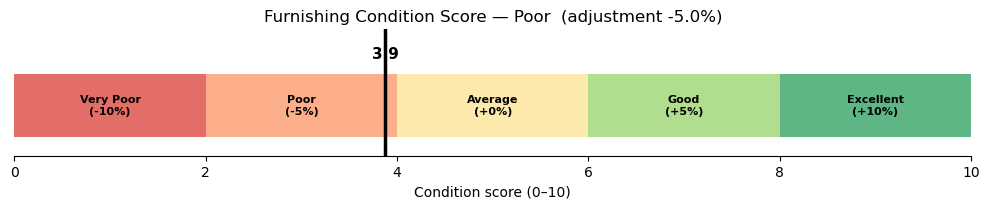

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 2.2))

# Tier bands
tier_colors = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']  # red → green
tier_data   = list(reversed(ADJUSTMENT_TIERS))  # draw 0-2 first (left)
for tier, color in zip(tier_data, tier_colors):
    ax.barh(
        0, tier['max'] - tier['min'],
        left=tier['min'], height=0.5,
        color=color, alpha=0.7,
    )
    mid = (tier['min'] + tier['max']) / 2
    ax.text(mid, 0, f"{tier['label']}\n({tier['pct']:+.0f}%)",
            ha='center', va='center', fontsize=8, fontweight='bold')

# Score needle
if result['photo_adjusted']:
    score = result['condition_score']
    ax.axvline(x=score, color='black', linewidth=2.5, zorder=5)
    ax.text(score, 0.35, f"{score:.1f}", ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='black')
    ax.set_title(f'Furnishing Condition Score — {result["tier_label"]}  '
                 f'(adjustment {result["adjustment_pct"]:+.1f}%)',
                 fontsize=12)
else:
    ax.set_title('Furnishing Condition Score — no photo provided', fontsize=12)

ax.set_xlim(0, 10)
ax.set_ylim(-0.4, 0.6)
ax.set_xlabel('Condition score (0–10)')
ax.set_yticks([])
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Summary table

In [6]:
import pandas as pd

rows = []

if result['base_predicted_price'] is not None:
    rows.append(('Base ML price (SGD)', f'{result["base_predicted_price"]:,.0f}'))
else:
    rows.append(('Base ML price (SGD)', 'N/A — bundle not loaded'))

if result['photo_adjusted']:
    rows += [
        ('Condition score', f'{result["condition_score"]:.2f} / 10'),
        ('Tier',            result['tier_label']),
        ('Adjustment',      f'{result["adjustment_pct"]:+.1f}%'),
    ]
    if result['adjusted_price'] is not None:
        rows.append(('Adjusted price (SGD)', f'{result["adjusted_price"]:,.0f}'))
else:
    rows.append(('Photo provided', 'No — base price used as final'))

rows += [
    ('Address lookup matched', str(result['lookup_matched'])),
]
if result.get('imputation_note'):
    rows.append(('Imputation note', result['imputation_note']))

summary = pd.DataFrame(rows, columns=['Field', 'Value'])
summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Field,Value
Base ML price (SGD),N/A — bundle not loaded
Condition score,3.88 / 10
Tier,Poor
Adjustment,-5.0%
Address lookup matched,False
